In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/HandSignRecognition

/content/drive/.shortcut-targets-by-id/1UJmXu-YyEkJR_7d3IvajQ3VL9AsHclRv/HandSignRecognition


Menghitung data dalam folder...
-> Kelas 'A': 2539 gambar
-> Kelas 'B': 2243 gambar
-> Kelas 'C': 2126 gambar
-> Kelas 'D': 2356 gambar
-> Kelas 'E': 2455 gambar
-> Kelas 'F': 2327 gambar
-> Kelas 'G': 2174 gambar
-> Kelas 'H': 1950 gambar
-> Kelas 'I': 2045 gambar
-> Kelas 'J': 1465 gambar
-> Kelas 'K': 2446 gambar
-> Kelas 'L': 2406 gambar
-> Kelas 'M': 2376 gambar
-> Kelas 'N': 2292 gambar
-> Kelas 'O': 2335 gambar
-> Kelas 'P': 1834 gambar
-> Kelas 'Q': 2215 gambar
-> Kelas 'R': 2352 gambar
-> Kelas 'S': 2431 gambar
-> Kelas 'T': 2621 gambar
-> Kelas 'U': 2370 gambar
-> Kelas 'V': 2237 gambar
-> Kelas 'W': 2336 gambar
-> Kelas 'X': 2501 gambar
-> Kelas 'Y': 2365 gambar
-> Kelas 'Z': 2073 gambar
-> Kelas '_blank_': 1525 gambar

Menampilkan grafik batang...


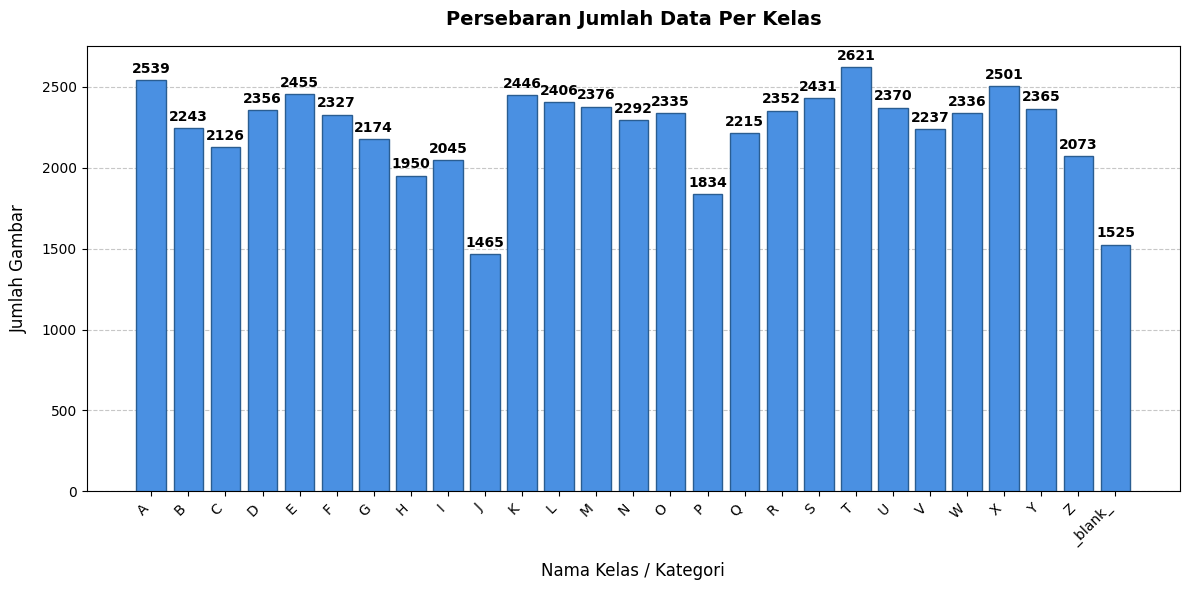

In [5]:
import os
from glob import glob
import matplotlib.pyplot as plt

DATASET_DIR = 'Dataset/CNN_Images_Cleaned'

def plot_persebaran_data():
    if not os.path.exists(DATASET_DIR):
        print(f"[ERROR] Folder dataset tidak ditemukan di: '{DATASET_DIR}'")
        return

    class_paths = sorted(glob(os.path.join(DATASET_DIR, '*')))

    if not class_paths:
        print(f"[ERROR] Tidak ada sub-folder kelas di dalam '{DATASET_DIR}'")
        return

    nama_kelas = []
    jumlah_gambar = []
    print("Menghitung data dalam folder...")
    for path in class_paths:
        kelas = os.path.basename(path)
        total_file = len(glob(os.path.join(path, '*')))

        nama_kelas.append(kelas)
        jumlah_gambar.append(total_file)
        print(f"-> Kelas '{kelas}': {total_file} gambar")

    plt.figure(figsize=(12, 6))
    bars = plt.bar(nama_kelas, jumlah_gambar, color='#4a90e2', edgecolor='#2a5d91', zorder=3)
    plt.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)

    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval + (max(jumlah_gambar) * 0.01),
                 f'{yval}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.title('Persebaran Jumlah Data Per Kelas', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Nama Kelas / Kategori', fontsize=12, labelpad=10)
    plt.ylabel('Jumlah Gambar', fontsize=12, labelpad=10)

    plt.xticks(rotation=45, ha='right')

    plt.tight_layout()
    print("\nMenampilkan grafik batang...")
    plt.show()

if __name__ == "__main__":
    plot_persebaran_data()

Memuat data langsung dari cache 'dataset_processed.npz'...
Data berhasil dimuat. Total data training tersedia: 48316
Menampilkan pop-up sampel gambar...


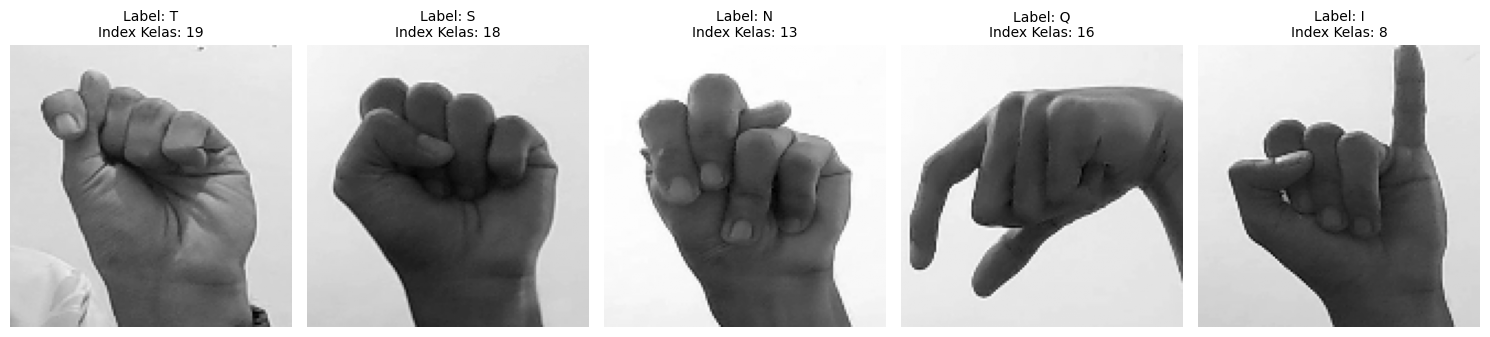

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os
from glob import glob

DATASET_DIR = 'Dataset/CNN_Images_Cleaned'
DATASET_SAVED_FILE = 'dataset_processed.npz'

def tampilkan_sampel_dari_cache(num_images=5):
    if not os.path.exists(DATASET_SAVED_FILE):
        print(f"[ERROR] File cache '{DATASET_SAVED_FILE}' tidak ditemukan!")
        print("Anda harus menjalankan script training utama minimal sekali sampai text 'Data sukses dicache!' muncul.")
        return

    print(f"Memuat data langsung dari cache '{DATASET_SAVED_FILE}'...")
    data = np.load(DATASET_SAVED_FILE)
    X_train = data['X_train']
    y_train = data['y_train']

    print(f"Data berhasil dimuat. Total data training tersedia: {len(X_train)}")

    classes = sorted([os.path.basename(x) for x in glob(os.path.join(DATASET_DIR, '*'))])
    indeks_acak = np.random.choice(len(X_train), num_images, replace=False)

    plt.figure(figsize=(15, 4))
    for i, idx in enumerate(indeks_acak):
        plt.subplot(1, num_images, i + 1)

        img = np.squeeze(X_train[idx])

        label_idx = np.argmax(y_train[idx])
        nama_kelas = classes[label_idx] if label_idx < len(classes) else f"Kelas {label_idx}"

        plt.imshow(img, cmap='gray')
        plt.title(f"Label: {nama_kelas}\nIndex Kelas: {label_idx}", fontsize=10)
        plt.axis('off')

    plt.tight_layout()
    print("Menampilkan pop-up sampel gambar...")
    plt.show()

if __name__ == "__main__":
    tampilkan_sampel_dari_cache(num_images=5)

In [ ]:
import numpy as np
import cv2
import os
from glob import glob
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import optimizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, Input, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.layers import RandomRotation, RandomZoom, RandomTranslation
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras import backend as K
from tensorflow.keras.regularizers import l2

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

print("\n=========================================")
gpus = tf.config.list_physical_devices('GPU')
print("Jumlah GPU Terdeteksi:", len(gpus))
if len(gpus) > 0:
    print("Nama GPU:", gpus)
    print("STATUS: Training akan berjalan menggunakan GPU!")
else:
    print("STATUS: Tidak ada GPU terdeteksi. Training menggunakan CPU.")
print("=========================================\n")

DATASET_DIR = 'Dataset/CNN_Images_Cleaned'
IMAGE_X, IMAGE_Y = 128, 128
DATASET_SAVED_FILE = 'dataset_processed.npz'

def get_num_of_classes():
    return len(glob(os.path.join(DATASET_DIR, '*')))

def load_dataset():
    images = []
    labels = []

    classes = sorted([os.path.basename(x) for x in glob(os.path.join(DATASET_DIR, '*'))])
    print(f"Membaca kelas: {classes}")

    for idx, class_name in enumerate(classes):
        class_path = os.path.join(DATASET_DIR, class_name)
        img_paths = glob(os.path.join(class_path, '*'))

        print(f"-> Memuat {len(img_paths)} gambar dari Kelas {class_name}...")

        for img_path in img_paths:
            try:
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                img = cv2.resize(img, (IMAGE_Y, IMAGE_X))

                images.append(img)
                labels.append(idx)
            except Exception as e:
                print(f"Gagal membaca {img_path}: {e}")

    return np.array(images), np.array(labels)

def cnn_model():
    num_of_classes = get_num_of_classes()
    model = Sequential()

    model.add(Input(shape=(IMAGE_X, IMAGE_Y, 1)))

    model.add(RandomRotation(0.08))
    model.add(RandomZoom(0.08))
    model.add(RandomTranslation(0.08, 0.08))

    model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

    model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

    model.add(GlobalAveragePooling2D())

    model.add(Dense(256, activation='relu', kernel_regularizer=l2(1e-4)))
    model.add(Dropout(0.4))
    model.add(Dense(num_of_classes, activation='softmax'))

    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

    filepath = "sign_language_best_model.keras"
    checkpoint1 = ModelCheckpoint(filepath, monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')

    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-5, verbose=1)
    callbacks_list = [checkpoint1, reduce_lr]

    return model, callbacks_list

def train():
    if os.path.exists(DATASET_SAVED_FILE):
        print(f"Menemukan cache dataset! Memuat langsung dari '{DATASET_SAVED_FILE}'...")

        data = np.load(DATASET_SAVED_FILE)
        X_train = data['X_train']
        X_val = data['X_val']
        y_train = data['y_train']
        y_val = data['y_val']

        print("Dataset berhasil dimuat ")
    else:
        print("Cache tidak ditemukan.")
        X, y = load_dataset()

        if len(X) == 0:
            print("\n[ERROR] Dataset kosong! Periksa kembali jalur DATASET_DIR Anda.")
            return

        print("\nMemisahkan dataset (80% Train, 20% Validasi)...")
        X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

        X_train = np.reshape(X_train, (X_train.shape[0], IMAGE_X, IMAGE_Y, 1))
        X_val = np.reshape(X_val, (X_val.shape[0], IMAGE_X, IMAGE_Y, 1))

        X_train = X_train.astype('float32') / 255.0
        X_val = X_val.astype('float32') / 255.0

        y_train = to_categorical(y_train)
        y_val = to_categorical(y_val)

        print(f"Menyimpan data hasil proses ke '{DATASET_SAVED_FILE}' untuk dijalankan berikutnya...")
        np.savez_compressed(DATASET_SAVED_FILE, X_train=X_train, X_val=X_val, y_train=y_train, y_val=y_val)
        print("Data sukses dicache!")

    print(f"Ukuran Akhir Data Training: {X_train.shape}")
    print(f"Ukuran Akhir Data Validasi: {X_val.shape}\n")

    model, callbacks_list = cnn_model()
    model.summary()

    print("\nMemulai proses melatih model (Training)...")

    model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, batch_size=64, callbacks=callbacks_list)

    scores = model.evaluate(X_val, y_val, verbose=0)
    print("\n=========================================")
    print("Selesai! Model terbaik otomatis disimpan sebagai: 'sign_language_best_model.keras'")
    print("Akurasi Validasi Akhir: %.2f%%" % (scores[1] * 100))
    print("CNN Error Rate: %.2f%%" % (100 - scores[1] * 100))
    print("=========================================")

    model.save('sign_language_final_model.keras')
    print("Model versi final berhasil disimpan secara manual!")

if __name__ == "__main__":
    train()
    K.clear_session()


Jumlah GPU Terdeteksi: 1
Nama GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
STATUS: Training akan berjalan menggunakan GPU! 🚀

🔍 Cache tidak ditemukan. Memulai pemrosesan dataset dari awal...
Membaca kelas: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', '_blank_']
-> Memuat 1907 gambar dari Kelas A...
-> Memuat 1619 gambar dari Kelas B...
-> Memuat 1761 gambar dari Kelas C...
-> Memuat 1691 gambar dari Kelas D...
-> Memuat 1780 gambar dari Kelas E...
-> Memuat 1685 gambar dari Kelas F...
-> Memuat 1666 gambar dari Kelas G...
-> Memuat 1551 gambar dari Kelas H...
-> Memuat 1413 gambar dari Kelas I...
-> Memuat 1465 gambar dari Kelas J...
-> Memuat 1789 gambar dari Kelas K...
-> Memuat 1758 gambar dari Kelas L...
-> Memuat 1728 gambar dari Kelas M...
-> Memuat 1658 gambar dari Kelas N...
-> Memuat 1714 gambar dari Kelas O...
-> Memuat 1753 gambar dari Kelas P...
-> Memuat 1642 g

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_rotation                 │ (None, 128, 128, 1)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 128, 128, 1)    │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,02

 Total params: 180,091 (703.48 KB)

 Trainable params: 179,451 (700.98 KB)

 Non-trainable params: 640 (2.50 KB)


Memulai proses melatih model (Training)...
Epoch 1/50
571/571 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.3907 - loss: 1.9905
Epoch 1: val_accuracy improved from None to 0.09099, saving model to sign_language_best_model.keras

Epoch 1: finished saving model to sign_language_best_model.keras
571/571 ━━━━━━━━━━━━━━━━━━━━ 115s 176ms/step - accuracy: 0.6091 - loss: 1.2702 - val_accuracy: 0.0910 - val_loss: 8.9080 - learning_rate: 0.0010
Epoch 2/50
571/571 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.9317 - loss: 0.2852
Epoch 2: val_accuracy improved from 0.09099 to 0.94646, saving model to sign_language_best_model.keras

Epoch 2: finished saving model to sign_language_best_model.keras
571/571 ━━━━━━━━━━━━━━━━━━━━ 102s 179ms/step - accuracy: 0.9484 - loss: 0.2220 - val_accuracy: 0.9465 - val_loss: 0.2117 - learning_rate: 0.0010
Epoch 3/50
571/571 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.9786 - loss: 0.1140
Epoch 3: val_accuracy improved from 0.94646 to 0.95456, saving mode


Memulai Proses Pembuatan Confusion Matrix...
-> Sedang memprediksi data validasi...
378/378 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step
-> Menampilkan grafik...


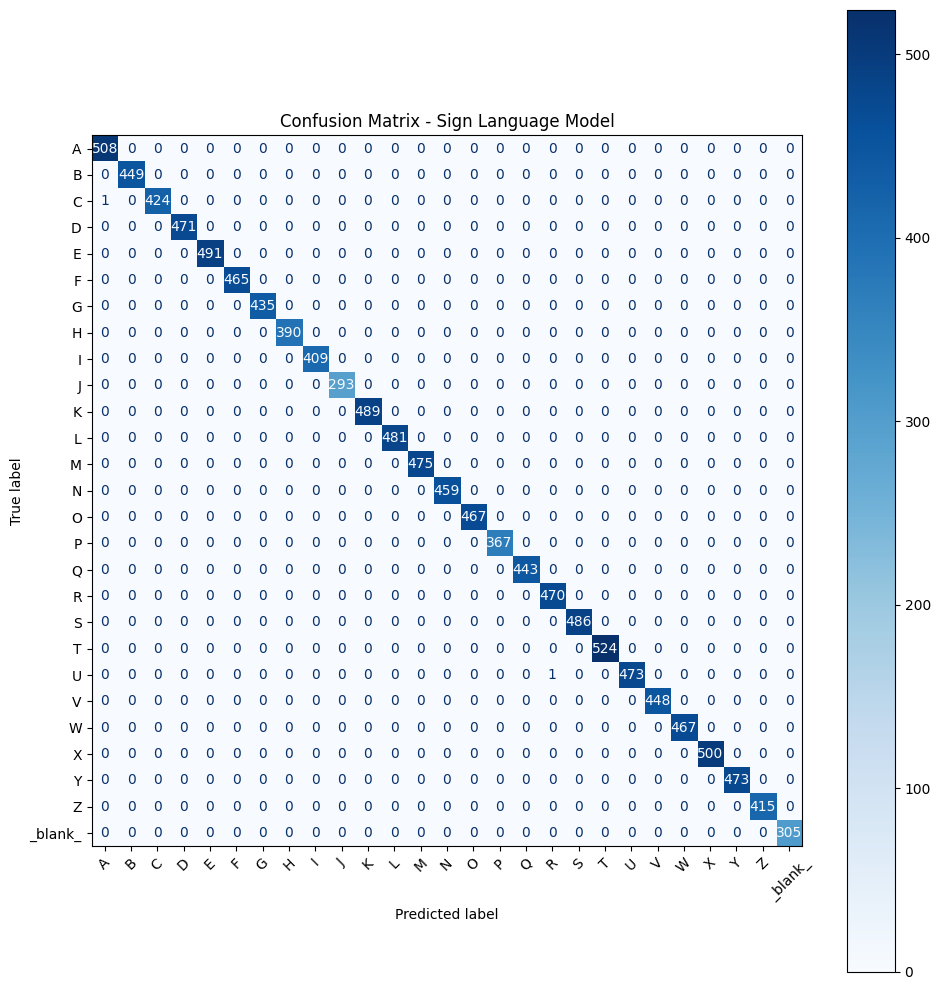

In [21]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from glob import glob
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras import backend as K


DATASET_SAVED_FILE = 'dataset_processed.npz'
DATASET_DIR = 'Dataset/CNN_Images_Cleaned'

def generate_confusion_matrix():
    print("\nMemulai Proses Pembuatan Confusion Matrix...")

    # 1. Pastikan cache dataset ada
    if not os.path.exists(DATASET_SAVED_FILE):
        print("[ERROR] Cache dataset tidak ditemukan. Jalankan training terlebih dahulu!")
        return

    data = np.load(DATASET_SAVED_FILE)
    X_val = data['X_val']
    y_val = data['y_val']

    model_path = "Model/CNN/cnn_best2.keras"
    if not os.path.exists(model_path):
        print(f"[ERROR] Model '{model_path}' tidak ditemukan!")
        return

    model = tf.keras.models.load_model(model_path)

    classes = sorted([os.path.basename(x) for x in glob(os.path.join(DATASET_DIR, '*'))])

    print("-> Sedang memprediksi data validasi...")
    y_pred_probs = model.predict(X_val)

    y_true = np.argmax(y_val, axis=1)
    y_pred = np.argmax(y_pred_probs, axis=1)

    cm = confusion_matrix(y_true, y_pred)

    print("-> Menampilkan grafik...")
    fig, ax = plt.subplots(figsize=(10, 10))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

    disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation=45)

    plt.title('Confusion Matrix - Sign Language Model')
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    generate_confusion_matrix()
    K.clear_session()

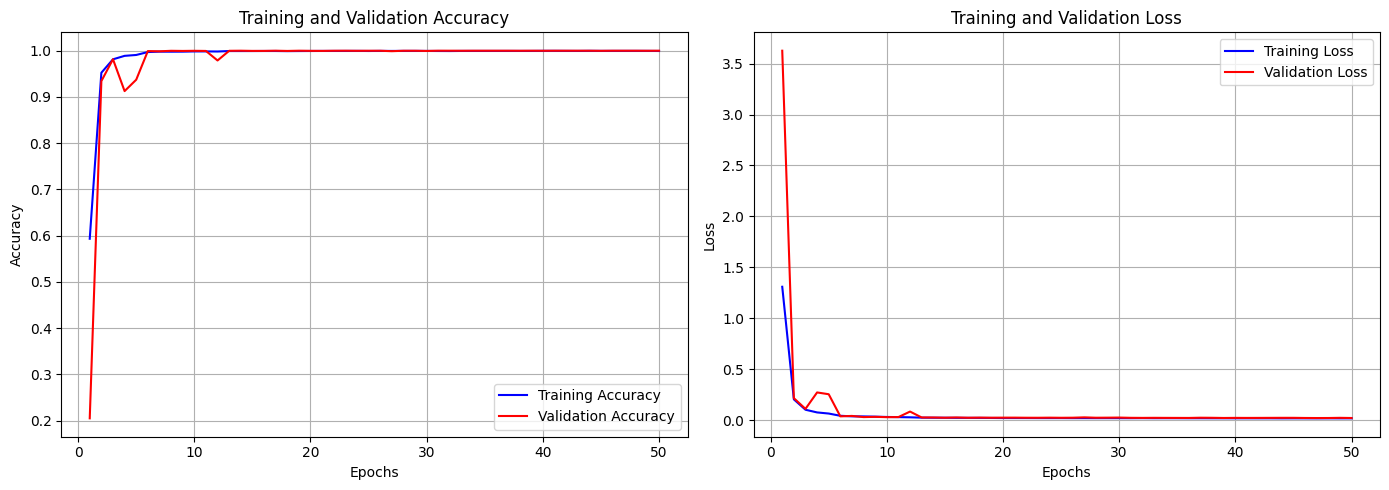

In [20]:
import re
import matplotlib.pyplot as plt

log_text = """
Epoch 1: finished saving model to sign_language_best_model.keras
755/755 ━━━━━━━━━━━━━━━━━━━━ 146s 177ms/step - accuracy: 0.5933 - loss: 1.3101 - val_accuracy: 0.2051 - val_loss: 3.6261 - learning_rate: 0.0010
Epoch 2: finished saving model to sign_language_best_model.keras
755/755 ━━━━━━━━━━━━━━━━━━━━ 131s 173ms/step - accuracy: 0.9522 - loss: 0.2054 - val_accuracy: 0.9341 - val_loss: 0.2172 - learning_rate: 0.0010
Epoch 3: finished saving model to sign_language_best_model.keras
755/755 ━━━━━━━━━━━━━━━━━━━━ 131s 174ms/step - accuracy: 0.9812 - loss: 0.1036 - val_accuracy: 0.9814 - val_loss: 0.1121 - learning_rate: 0.0010
Epoch 4: val_accuracy did not improve from 0.98137
755/755 ━━━━━━━━━━━━━━━━━━━━ 130s 173ms/step - accuracy: 0.9887 - loss: 0.0772 - val_accuracy: 0.9125 - val_loss: 0.2733 - learning_rate: 0.0010
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
755/755 ━━━━━━━━━━━━━━━━━━━━ 131s 173ms/step - accuracy: 0.9906 - loss: 0.0663 - val_accuracy: 0.9371 - val_loss: 0.2557 - learning_rate: 0.0010
Epoch 6: finished saving model to sign_language_best_model.keras
755/755 ━━━━━━━━━━━━━━━━━━━━ 131s 173ms/step - accuracy: 0.9969 - loss: 0.0443 - val_accuracy: 0.9990 - val_loss: 0.0386 - learning_rate: 2.0000e-04
Epoch 7: val_accuracy did not improve from 0.99901
755/755 ━━━━━━━━━━━━━━━━━━━━ 131s 173ms/step - accuracy: 0.9978 - loss: 0.0389 - val_accuracy: 0.9985 - val_loss: 0.0429 - learning_rate: 2.0000e-04
Epoch 8: finished saving model to sign_language_best_model.keras
755/755 ━━━━━━━━━━━━━━━━━━━━ 131s 173ms/step - accuracy: 0.9977 - loss: 0.0381 - val_accuracy: 0.9996 - val_loss: 0.0315 - learning_rate: 2.0000e-04
Epoch 9: val_accuracy did not improve from 0.99959
755/755 ━━━━━━━━━━━━━━━━━━━━ 131s 173ms/step - accuracy: 0.9978 - loss: 0.0357 - val_accuracy: 0.9993 - val_loss: 0.0339 - learning_rate: 2.0000e-04
Epoch 10: val_accuracy did not improve from 0.99959
755/755 ━━━━━━━━━━━━━━━━━━━━ 131s 173ms/step - accuracy: 0.9983 - loss: 0.0326 - val_accuracy: 0.9996 - val_loss: 0.0308 - learning_rate: 2.0000e-04
Epoch 11: val_accuracy did not improve from 0.99959
755/755 ━━━━━━━━━━━━━━━━━━━━ 131s 173ms/step - accuracy: 0.9983 - loss: 0.0312 - val_accuracy: 0.9993 - val_loss: 0.0316 - learning_rate: 2.0000e-04
Epoch 12: ReduceLROnPlateau reducing learning rate to 4.0000001899898055e-05.
755/755 ━━━━━━━━━━━━━━━━━━━━ 131s 173ms/step - accuracy: 0.9981 - loss: 0.0293 - val_accuracy: 0.9787 - val_loss: 0.0857 - learning_rate: 2.0000e-04
Epoch 13: val_accuracy did not improve from 0.99959
755/755 ━━━━━━━━━━━━━━━━━━━━ 131s 173ms/step - accuracy: 0.9991 - loss: 0.0259 - val_accuracy: 0.9996 - val_loss: 0.0277 - learning_rate: 4.0000e-05
Epoch 14: finished saving model to sign_language_best_model.keras
755/755 ━━━━━━━━━━━━━━━━━━━━ 131s 173ms/step - accuracy: 0.9991 - loss: 0.0253 - val_accuracy: 0.9998 - val_loss: 0.0274 - learning_rate: 4.0000e-05
Epoch 15: val_accuracy did not improve from 0.99983
755/755 ━━━━━━━━━━━━━━━━━━━━ 131s 173ms/step - accuracy: 0.9991 - loss: 0.0250 - val_accuracy: 0.9994 - val_loss: 0.0253 - learning_rate: 4.0000e-05
Epoch 16: val_accuracy did not improve from 0.99983
755/755 ━━━━━━━━━━━━━━━━━━━━ 131s 173ms/step - accuracy: 0.9992 - loss: 0.0241 - val_accuracy: 0.9994 - val_loss: 0.0277 - learning_rate: 4.0000e-05
Epoch 17: val_accuracy did not improve from 0.99983
755/755 ━━━━━━━━━━━━━━━━━━━━ 131s 173ms/step - accuracy: 0.9992 - loss: 0.0239 - val_accuracy: 0.9998 - val_loss: 0.0250 - learning_rate: 4.0000e-05
Epoch 18: val_accuracy did not improve from 0.99983
755/755 ━━━━━━━━━━━━━━━━━━━━ 131s 173ms/step - accuracy: 0.9989 - loss: 0.0236 - val_accuracy: 0.9993 - val_loss: 0.0263 - learning_rate: 4.0000e-05
Epoch 19: ReduceLROnPlateau reducing learning rate to 1e-05.
755/755 ━━━━━━━━━━━━━━━━━━━━ 131s 174ms/step - accuracy: 0.9991 - loss: 0.0229 - val_accuracy: 0.9998 - val_loss: 0.0252 - learning_rate: 4.0000e-05
Epoch 20: val_accuracy did not improve from 0.99983
755/755 ━━━━━━━━━━━━━━━━━━━━ 131s 173ms/step - accuracy: 0.9992 - loss: 0.0222 - val_accuracy: 0.9995 - val_loss: 0.0259 - learning_rate: 1.0000e-05
Epoch 21: val_accuracy did not improve from 0.99983
755/755 ━━━━━━━━━━━━━━━━━━━━ 131s 173ms/step - accuracy: 0.9993 - loss: 0.0221 - val_accuracy: 0.9994 - val_loss: 0.0261 - learning_rate: 1.0000e-05
Epoch 22: val_accuracy did not improve from 0.99983
755/755 ━━━━━━━━━━━━━━━━━━━━ 131s 173ms/step - accuracy: 0.9993 - loss: 0.0220 - val_accuracy: 0.9997 - val_loss: 0.0251 - learning_rate: 1.0000e-05
Epoch 23: val_accuracy did not improve from 0.99983
755/755 ━━━━━━━━━━━━━━━━━━━━ 131s 173ms/step - accuracy: 0.9993 - loss: 0.0217 - val_accuracy: 0.9998 - val_loss: 0.0248 - learning_rate: 1.0000e-05
Epoch 24: val_accuracy did not improve from 0.99983
755/755 ━━━━━━━━━━━━━━━━━━━━ 136s 180ms/step - accuracy: 0.9994 - loss: 0.0217 - val_accuracy: 0.9996 - val_loss: 0.0258 - learning_rate: 1.0000e-05
Epoch 25: val_accuracy did not improve from 0.99983
755/755 ━━━━━━━━━━━━━━━━━━━━ 131s 173ms/step - accuracy: 0.9992 - loss: 0.0217 - val_accuracy: 0.9997 - val_loss: 0.0247 - learning_rate: 1.0000e-05
Epoch 26: val_accuracy did not improve from 0.99983
755/755 ━━━━━━━━━━━━━━━━━━━━ 136s 180ms/step - accuracy: 0.9994 - loss: 0.0213 - val_accuracy: 0.9997 - val_loss: 0.0254 - learning_rate: 1.0000e-05
Epoch 27: val_accuracy did not improve from 0.99983
755/755 ━━━━━━━━━━━━━━━━━━━━ 131s 173ms/step - accuracy: 0.9993 - loss: 0.0215 - val_accuracy: 0.9988 - val_loss: 0.0288 - learning_rate: 1.0000e-05
Epoch 28: val_accuracy did not improve from 0.99983
755/755 ━━━━━━━━━━━━━━━━━━━━ 131s 173ms/step - accuracy: 0.9994 - loss: 0.0211 - val_accuracy: 0.9997 - val_loss: 0.0252 - learning_rate: 1.0000e-05
Epoch 29: val_accuracy did not improve from 0.99983
755/755 ━━━━━━━━━━━━━━━━━━━━ 131s 173ms/step - accuracy: 0.9994 - loss: 0.0213 - val_accuracy: 0.9997 - val_loss: 0.0258 - learning_rate: 1.0000e-05
Epoch 30: val_accuracy did not improve from 0.99983
755/755 ━━━━━━━━━━━━━━━━━━━━ 131s 174ms/step - accuracy: 0.9993 - loss: 0.0212 - val_accuracy: 0.9993 - val_loss: 0.0268 - learning_rate: 1.0000e-05
Epoch 31: val_accuracy did not improve from 0.99983
755/755 ━━━━━━━━━━━━━━━━━━━━ 131s 173ms/step - accuracy: 0.9992 - loss: 0.0208 - val_accuracy: 0.9998 - val_loss: 0.0243 - learning_rate: 1.0000e-05
Epoch 32: val_accuracy did not improve from 0.99983
755/755 ━━━━━━━━━━━━━━━━━━━━ 131s 173ms/step - accuracy: 0.9991 - loss: 0.0213 - val_accuracy: 0.9998 - val_loss: 0.0236 - learning_rate: 1.0000e-05
Epoch 33: val_accuracy did not improve from 0.99983
755/755 ━━━━━━━━━━━━━━━━━━━━ 131s 173ms/step - accuracy: 0.9993 - loss: 0.0207 - val_accuracy: 0.9997 - val_loss: 0.0242 - learning_rate: 1.0000e-05
Epoch 34: val_accuracy did not improve from 0.99983
755/755 ━━━━━━━━━━━━━━━━━━━━ 131s 173ms/step - accuracy: 0.9993 - loss: 0.0208 - val_accuracy: 0.9998 - val_loss: 0.0237 - learning_rate: 1.0000e-05
Epoch 35: val_accuracy did not improve from 0.99983
755/755 ━━━━━━━━━━━━━━━━━━━━ 131s 173ms/step - accuracy: 0.9993 - loss: 0.0207 - val_accuracy: 0.9998 - val_loss: 0.0234 - learning_rate: 1.0000e-05
Epoch 36: val_accuracy did not improve from 0.99983
755/755 ━━━━━━━━━━━━━━━━━━━━ 131s 173ms/step - accuracy: 0.9993 - loss: 0.0203 - val_accuracy: 0.9998 - val_loss: 0.0231 - learning_rate: 1.0000e-05
Epoch 37: val_accuracy did not improve from 0.99983
755/755 ━━━━━━━━━━━━━━━━━━━━ 130s 173ms/step - accuracy: 0.9993 - loss: 0.0205 - val_accuracy: 0.9998 - val_loss: 0.0253 - learning_rate: 1.0000e-05
Epoch 38: val_accuracy did not improve from 0.99983
755/755 ━━━━━━━━━━━━━━━━━━━━ 131s 173ms/step - accuracy: 0.9993 - loss: 0.0202 - val_accuracy: 0.9997 - val_loss: 0.0245 - learning_rate: 1.0000e-05
Epoch 39: val_accuracy did not improve from 0.99983
755/755 ━━━━━━━━━━━━━━━━━━━━ 131s 173ms/step - accuracy: 0.9993 - loss: 0.0200 - val_accuracy: 0.9998 - val_loss: 0.0228 - learning_rate: 1.0000e-05
Epoch 40: val_accuracy did not improve from 0.99983
755/755 ━━━━━━━━━━━━━━━━━━━━ 130s 173ms/step - accuracy: 0.9995 - loss: 0.0198 - val_accuracy: 0.9997 - val_loss: 0.0237 - learning_rate: 1.0000e-05
Epoch 41: val_accuracy did not improve from 0.99983
755/755 ━━━━━━━━━━━━━━━━━━━━ 131s 173ms/step - accuracy: 0.9995 - loss: 0.0198 - val_accuracy: 0.9998 - val_loss: 0.0233 - learning_rate: 1.0000e-05
Epoch 42: val_accuracy did not improve from 0.99983
755/755 ━━━━━━━━━━━━━━━━━━━━ 136s 180ms/step - accuracy: 0.9994 - loss: 0.0197 - val_accuracy: 0.9998 - val_loss: 0.0235 - learning_rate: 1.0000e-05
Epoch 43: val_accuracy did not improve from 0.99983
755/755 ━━━━━━━━━━━━━━━━━━━━ 131s 173ms/step - accuracy: 0.9993 - loss: 0.0198 - val_accuracy: 0.9998 - val_loss: 0.0239 - learning_rate: 1.0000e-05
Epoch 44: val_accuracy did not improve from 0.99983
755/755 ━━━━━━━━━━━━━━━━━━━━ 132s 175ms/step - accuracy: 0.9995 - loss: 0.0193 - val_accuracy: 0.9998 - val_loss: 0.0243 - learning_rate: 1.0000e-05
Epoch 45: val_accuracy did not improve from 0.99983
755/755 ━━━━━━━━━━━━━━━━━━━━ 131s 173ms/step - accuracy: 0.9994 - loss: 0.0196 - val_accuracy: 0.9996 - val_loss: 0.0242 - learning_rate: 1.0000e-05
Epoch 46: val_accuracy did not improve from 0.99983
755/755 ━━━━━━━━━━━━━━━━━━━━ 131s 174ms/step - accuracy: 0.9994 - loss: 0.0194 - val_accuracy: 0.9998 - val_loss: 0.0228 - learning_rate: 1.0000e-05
Epoch 47: val_accuracy did not improve from 0.99983
755/755 ━━━━━━━━━━━━━━━━━━━━ 131s 174ms/step - accuracy: 0.9994 - loss: 0.0192 - val_accuracy: 0.9998 - val_loss: 0.0222 - learning_rate: 1.0000e-05
Epoch 48: val_accuracy did not improve from 0.99983
755/755 ━━━━━━━━━━━━━━━━━━━━ 136s 181ms/step - accuracy: 0.9994 - loss: 0.0196 - val_accuracy: 0.9998 - val_loss: 0.0225 - learning_rate: 1.0000e-05
Epoch 49: val_accuracy did not improve from 0.99983
755/755 ━━━━━━━━━━━━━━━━━━━━ 131s 174ms/step - accuracy: 0.9994 - loss: 0.0193 - val_accuracy: 0.9997 - val_loss: 0.0242 - learning_rate: 1.0000e-05
Epoch 50: val_accuracy did not improve from 0.99983
755/755 ━━━━━━━━━━━━━━━━━━━━ 132s 174ms/step - accuracy: 0.9992 - loss: 0.0194 - val_accuracy: 0.9998 - val_loss: 0.0225 - learning_rate: 1.0000e-05
"""

history = {
    'accuracy': [float(x) for x in re.findall(r' - accuracy: (\d+\.\d+)', log_text)],
    'loss': [float(x) for x in re.findall(r' - loss: (\d+\.\d+)', log_text)],
    'val_accuracy': [float(x) for x in re.findall(r' - val_accuracy: (\d+\.\d+)', log_text)],
    'val_loss': [float(x) for x in re.findall(r' - val_loss: (\d+\.\d+)', log_text)]
}

epochs = range(1, len(history['accuracy']) + 1)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, history['accuracy'], 'b-', label='Training Accuracy')
plt.plot(epochs, history['val_accuracy'], 'r-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, history['loss'], 'b-', label='Training Loss')
plt.plot(epochs, history['val_loss'], 'r-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()